In [1]:
from transformers import pipeline
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
pipe1 = pipeline('image-classification', model="dima806/crime_cctv_image_detection", device=0)
pipe2 = pipeline('image-classification', model="dima806/crime_type_cctv_image_detection", device=0)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0
Device set to use mps:0


In [3]:
def pipe(image, pipe1, pipe2):
    res1 = pipe1(image)

    crime_score = 0
    for r in res1:
        if r["label"] == "Crime":
            crime_score = r["score"]
            break
    
    if crime_score > 0.5:
        res2 = pipe2(image)
        predicted_label = res2[0]["label"] if len(res2) > 0 else "Unknown"
        return crime_score, predicted_label
    
    return crime_score, "Normal"

In [4]:
def resize(img, target_size=64):
    img.thumbnail((target_size, target_size), Image.LANCZOS)
    new_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))

    x = (target_size - img.width) // 2
    y = (target_size - img.height) // 2
    new_img.paste(img, (x, y))

    return new_img

## Test with image

(0.002278961706906557, 'Normal')


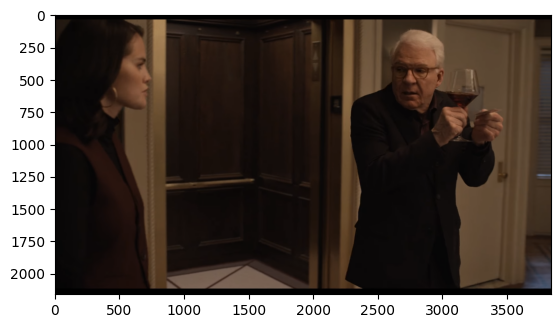

In [5]:
img = Image.open("3.png")
plt.imshow(img)
print(pipe(img, pipe1, pipe2))

(0.0002295412850799039, 'Normal')


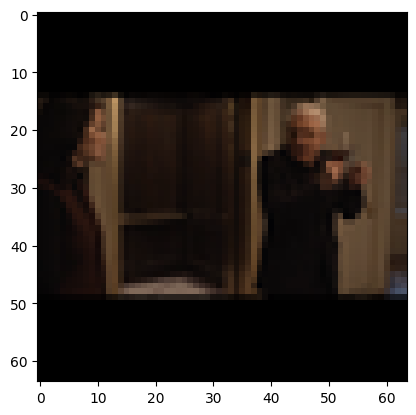

In [6]:
img = Image.open("3.png")

outJPG = resize(img, 64)
outJPG.save("output.jpg")

print(pipe(outJPG, pipe1, pipe2))
plt.imshow(outJPG)

(0.9997597336769104, 'Abuse')


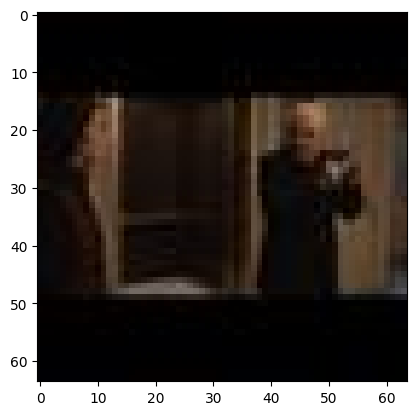

In [7]:
outJPG = Image.open("output.jpg")

print(pipe(outJPG, pipe1, pipe2))
plt.imshow(outJPG)